In [4]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import skimage as sk
from skimage.data import binary_blobs
from skimage.filters import threshold_otsu
from skimage.measure import label, regionprops, regionprops_table
from skimage.feature.texture import graycomatrix, graycoprops
from skimage import img_as_ubyte

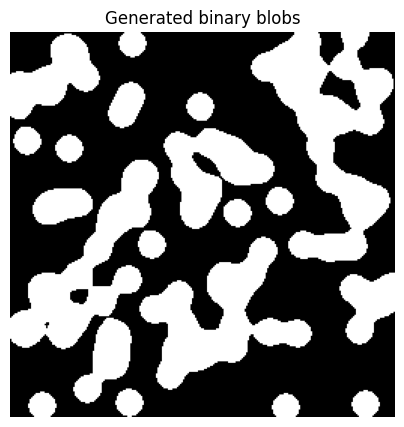

In [6]:
blobs = binary_blobs(length=256, blob_size_fraction=0.1, volume_fraction=0.4, rng=42)  # rng= is the correct param

fig = plt.figure(figsize=(5, 5))
plt.imshow(blobs, cmap='gray')
plt.title('Generated binary blobs')
plt.axis('off')
plt.show()

Number of regions found: 20


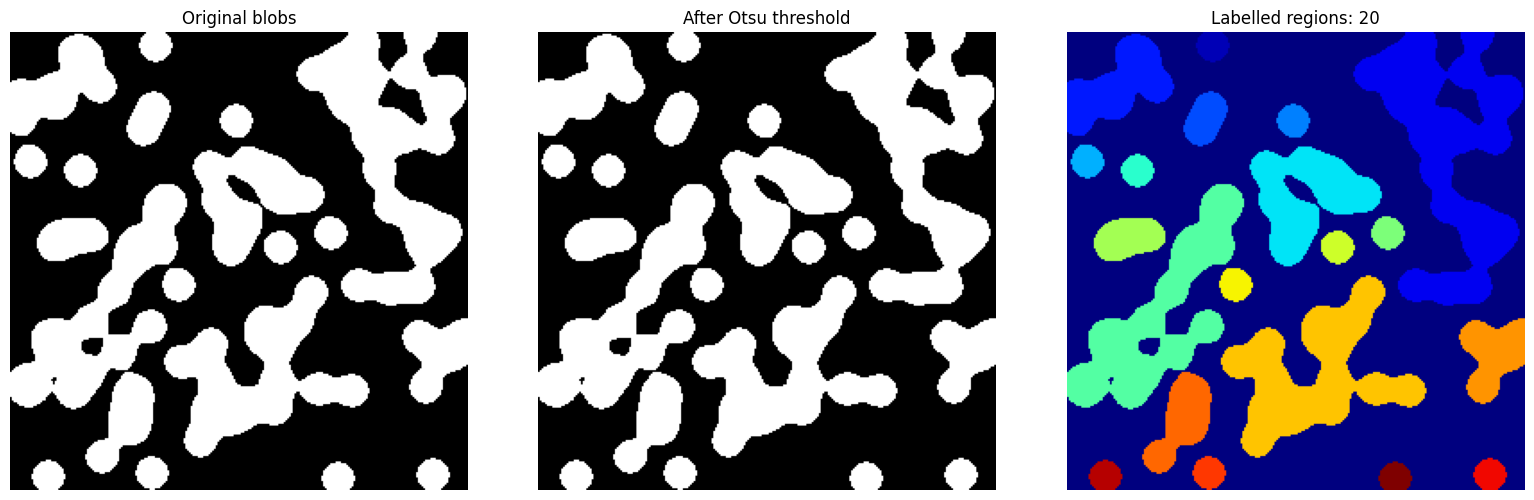

In [7]:
# blobs are already binary, but apply Otsu to simulate full pipeline like the lecture
thresh = threshold_otsu(blobs.astype(np.uint8))  # Otsu threshold
bw = blobs > thresh                               # binary segmentation

label_image, nregions = label(bw, return_num=True)  # label connected regions

print('Number of regions found: {}'.format(nregions))

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
axes[0].imshow(blobs, cmap='gray')
axes[0].set_title('Original blobs')
axes[0].axis('off')
axes[1].imshow(bw, cmap='gray')
axes[1].set_title('After Otsu threshold')
axes[1].axis('off')
axes[2].imshow(label_image, cmap='jet')
axes[2].set_title('Labelled regions: {}'.format(nregions))
axes[2].axis('off')
plt.tight_layout()
plt.show()

In [8]:
table = regionprops_table(label_image, properties=['label', 'area', 'major_axis_length',
                                                    'minor_axis_length', 'eccentricity',
                                                    'perimeter', 'solidity'])
df = pd.DataFrame(table)
print(df.head(10))

   label    area  major_axis_length  minor_axis_length  eccentricity  \
0      1   249.0          18.565417          17.131926      0.385310   
1      2  6352.0         181.162551          79.606356      0.898282   
2      3  1800.0          73.218484          37.098411      0.862134   
3      4   527.0          32.712636          20.624802      0.776202   
4      5   268.0          18.877348          18.095289      0.284852   
5      6   269.0          18.900354          18.144377      0.279993   
6      7  2596.0          72.545852          61.794728      0.523863   
7      8   262.0          18.344749          18.203263      0.123959   
8      9  4430.0         161.462370          52.096997      0.946516   
9     10   268.0          18.745706          18.216078      0.236026   

    perimeter  solidity  
0   56.284271  0.976471  
1  718.139177  0.543045  
2  209.923882  0.811542  
3   88.083261  0.959927  
4   58.526912  0.971014  
5   58.526912  0.971119  
6  307.806133  0.793156  

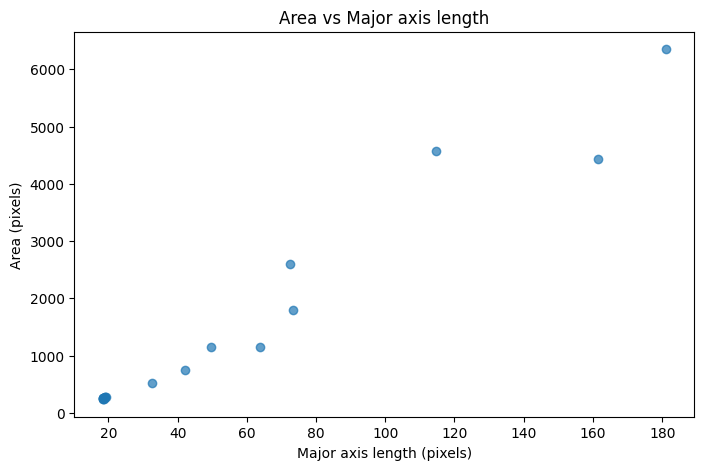

In [9]:
fig = plt.figure(figsize=(8, 5))
plt.scatter(df['major_axis_length'], df['area'], alpha=0.7)
plt.xlabel('Major axis length (pixels)')
plt.ylabel('Area (pixels)')
plt.title('Area vs Major axis length')
plt.show()
# clear correlation: longer blobs have bigger area

In [10]:
mean_area = df['area'].mean()
print('Average blob area: {:.1f} pixels'.format(mean_area))

large_blobs = df[df['area'] >= mean_area]
small_blobs  = df[df['area'] <  mean_area]

print('Blobs above average: {}'.format(len(large_blobs)))
print('Blobs below average: {}'.format(len(small_blobs)))

large_labels = large_blobs['label'].values
small_labels  = small_blobs['label'].values

Average blob area: 1310.8 pixels
Blobs above average: 5
Blobs below average: 15


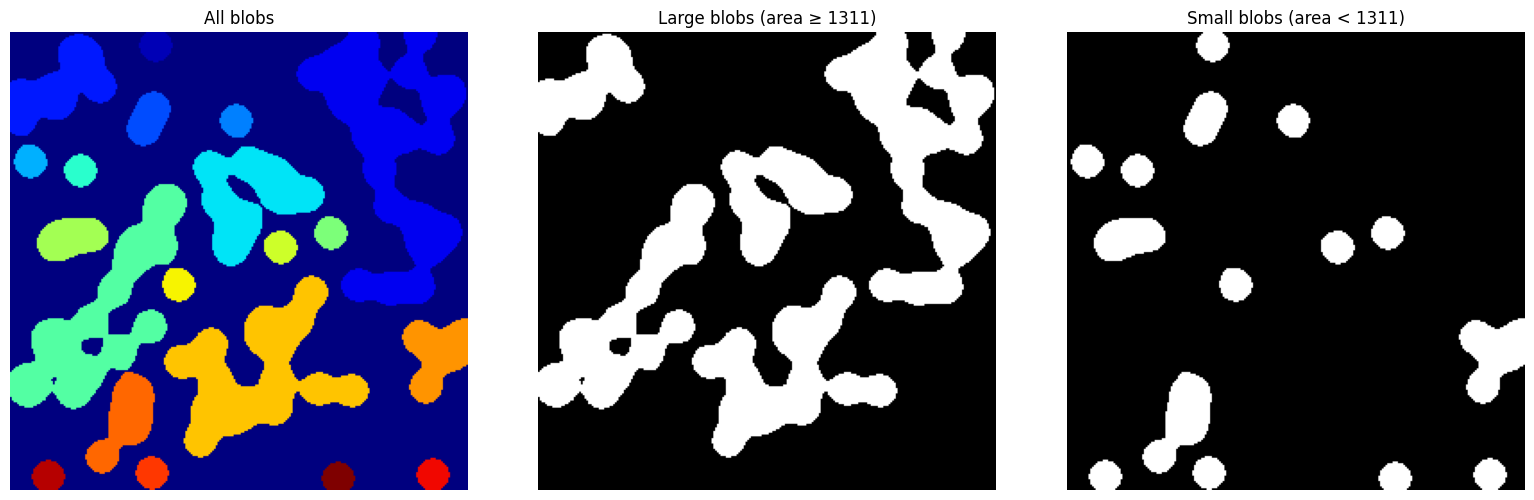

In [11]:
mask_large = np.isin(label_image, large_labels)
mask_small  = np.isin(label_image, small_labels)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
axes[0].imshow(label_image, cmap='jet')
axes[0].set_title('All blobs')
axes[0].axis('off')
axes[1].imshow(mask_large, cmap='gray')
axes[1].set_title('Large blobs (area ≥ {:.0f})'.format(mean_area))
axes[1].axis('off')
axes[2].imshow(mask_small, cmap='gray')
axes[2].set_title('Small blobs (area < {:.0f})'.format(mean_area))
axes[2].axis('off')
plt.tight_layout()
plt.show()

In [12]:
IG = img_as_ubyte(blobs)  # uint8 for GLCM
props = regionprops(label_image, intensity_image=IG)
nregions = len(props)

props_texture = np.zeros((nregions, 5))

for i, p in enumerate(props):
    minr, minc, maxr, maxc = p.bbox
    region_img = IG[minr:maxr, minc:maxc]

    if region_img.size == 0:
        continue

    g = graycomatrix(region_img, distances=[1], angles=[0],
                     levels=256, normed=True, symmetric=True)

    props_texture[i, 0] = graycoprops(g, 'contrast')[0, 0]
    props_texture[i, 1] = graycoprops(g, 'dissimilarity')[0, 0]
    props_texture[i, 2] = graycoprops(g, 'homogeneity')[0, 0]
    props_texture[i, 3] = graycoprops(g, 'energy')[0, 0]
    props_texture[i, 4] = graycoprops(g, 'correlation')[0, 0]

df_texture = pd.DataFrame(props_texture,
                           columns=['Contrast','Dissimilarity','Homogeneity','Energy','Correlation'])
print(df_texture.head(10))

      Contrast  Dissimilarity  Homogeneity    Energy  Correlation
0  5950.000000      23.333333     0.908498  0.775633     0.709756
1  2242.553191       8.794326     0.965513  0.683178     0.931021
2  1914.206066       7.506690     0.970562  0.687971     0.940902
3  4719.556452      18.508065     0.927420  0.717684     0.826203
4  6084.210526      23.859649     0.906434  0.752514     0.731830
5  5894.078947      23.114035     0.909358  0.755165     0.739005
6  3110.989573      12.199959     0.952158  0.688411     0.900438
7  5894.078947      23.114035     0.909358  0.740601     0.754410
8  2343.385569       9.189747     0.963962  0.682357     0.927873
9  5703.947368      22.368421     0.912282  0.753570     0.750874


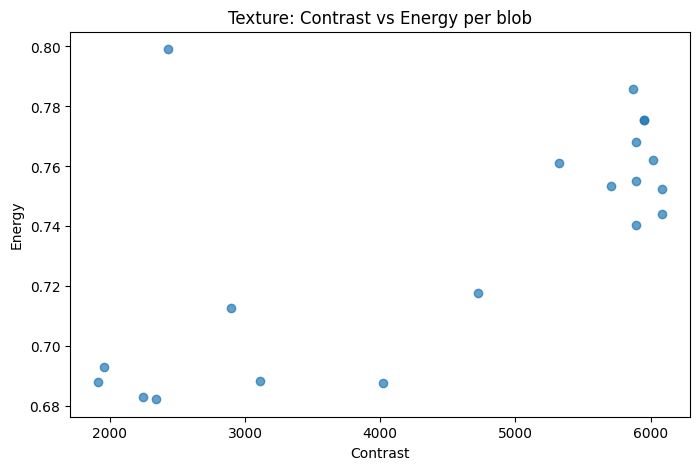

In [13]:
fig = plt.figure(figsize=(8, 5))
plt.scatter(df_texture['Contrast'], df_texture['Energy'], alpha=0.7)
plt.xlabel('Contrast')
plt.ylabel('Energy')
plt.title('Texture: Contrast vs Energy per blob')
plt.show()
# uniform blobs have low contrast and high energy